In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
happiness = pd.read_csv("/content/drive/MyDrive/invierno 2025/Semana TEC python/Happiness_report.csv")


In [58]:
mexico = happiness[happiness['Country or region'] == 'Mexico']
mexico.set_index('Country or region', inplace=True)

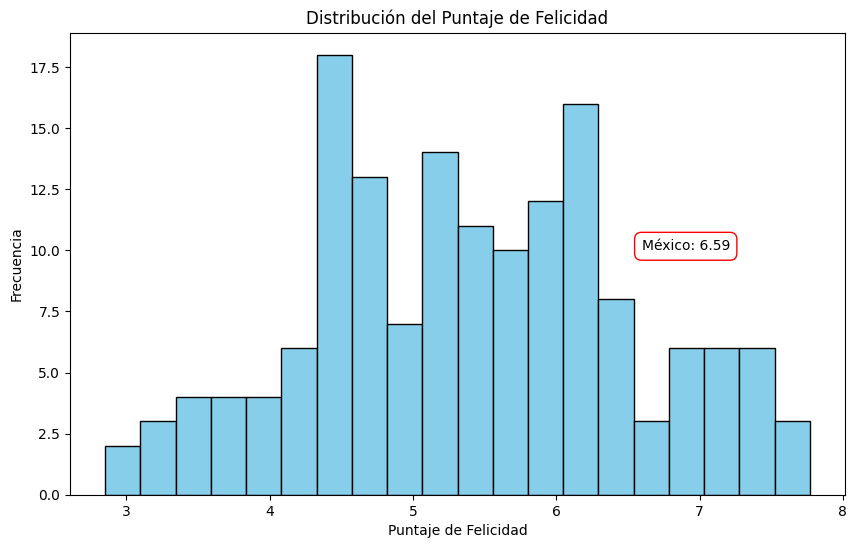

In [59]:
score_mexico = mexico["Score"].values[0]

plt.figure(figsize=(10, 6))
plt.hist(happiness["Score"], bins=20, color="skyblue", edgecolor="black")

plt.text(score_mexico, 10, f"México: {score_mexico:.2f}",
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.5'))

plt.title("Distribución del Puntaje de Felicidad")
plt.xlabel("Puntaje de Felicidad")
plt.ylabel("Frecuencia")
plt.show()

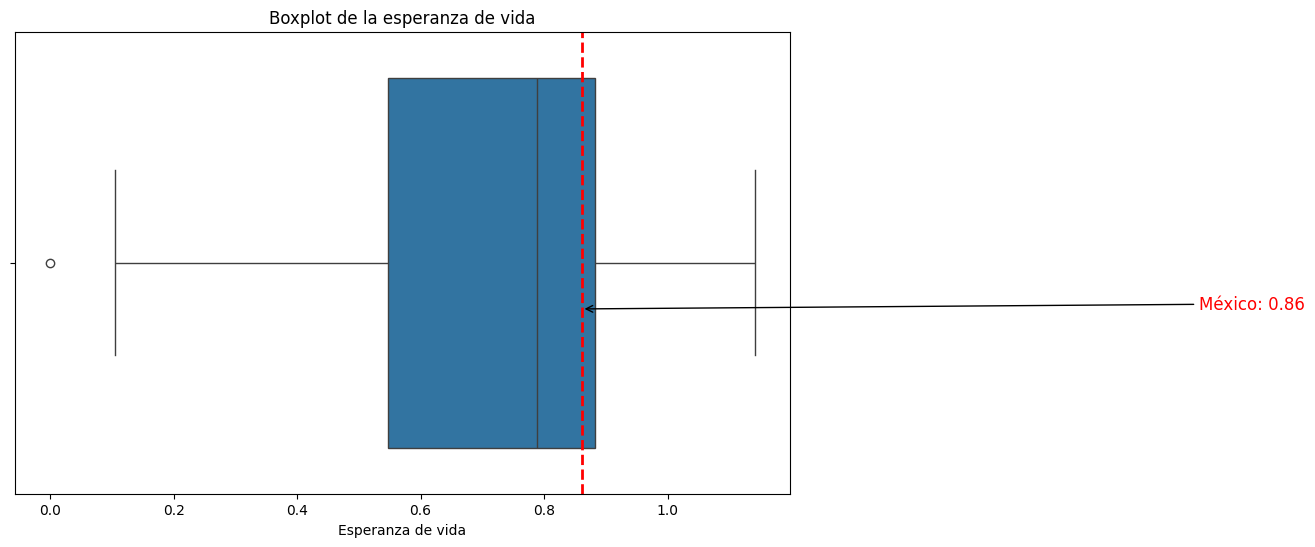

In [60]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=happiness['Healthy life expectancy'])
plt.axvline(mexico['Healthy life expectancy'].values[0], color='red', linestyle='dashed', linewidth=2)
plt.annotate(f"México: {life_mexico:.2f}",
             xy=(life_mexico,0.1),
             xytext=(life_mexico + 1, 0.1),
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=12, color='red')
plt.title('Boxplot de la esperanza de vida')
plt.xlabel('Esperanza de vida')
plt.show()

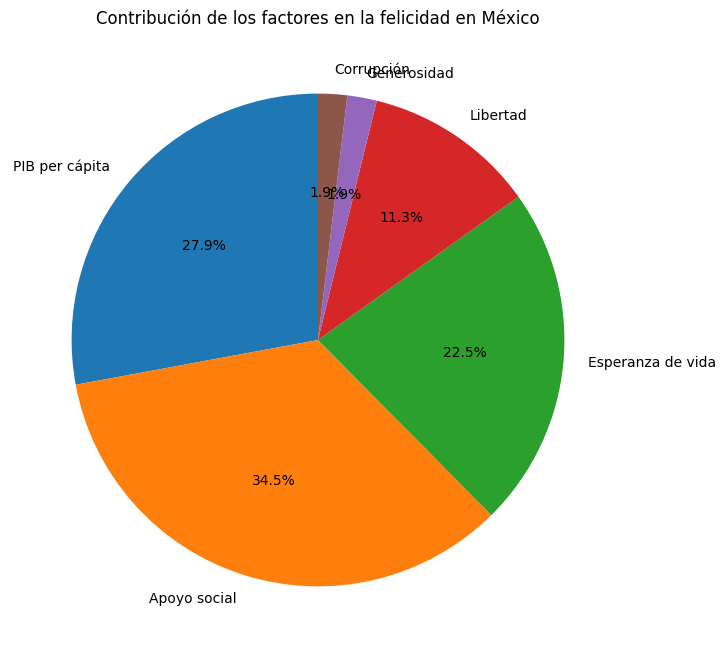

In [61]:
factores_mexico = mexico[['GDP per capita', 'Social support', 'Healthy life expectancy',
                          'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']].values[0]
labels = ['PIB per cápita', 'Apoyo social', 'Esperanza de vida', 'Libertad', 'Generosidad', 'Corrupción']

plt.figure(figsize=(8, 8))
plt.pie(factores_mexico, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Contribución de los factores en la felicidad en México')
plt.show()

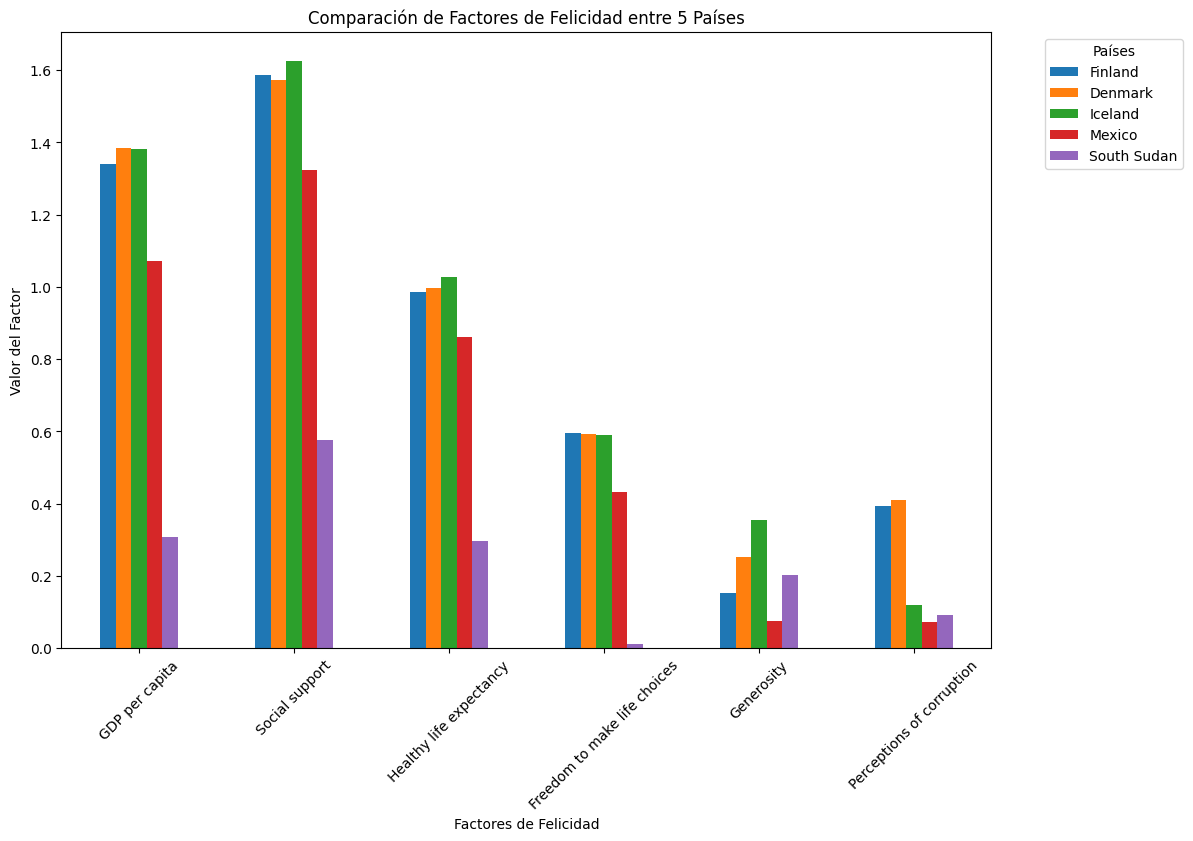

In [62]:
top_5_paises = happiness[happiness['Country or region'].isin(['Finland', 'South Sudan', 'Mexico', 'Denmark', 'Iceland'])]

top_5_paises.set_index('Country or region')[['GDP per capita', 'Social support', 'Healthy life expectancy',
                                             'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']].T.plot(
    kind='bar', figsize=(12, 8))

plt.title('Comparación de Factores de Felicidad entre 5 Países')
plt.xlabel('Factores de Felicidad')
plt.ylabel('Valor del Factor')
plt.xticks(rotation=45)
plt.legend(title="Países", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

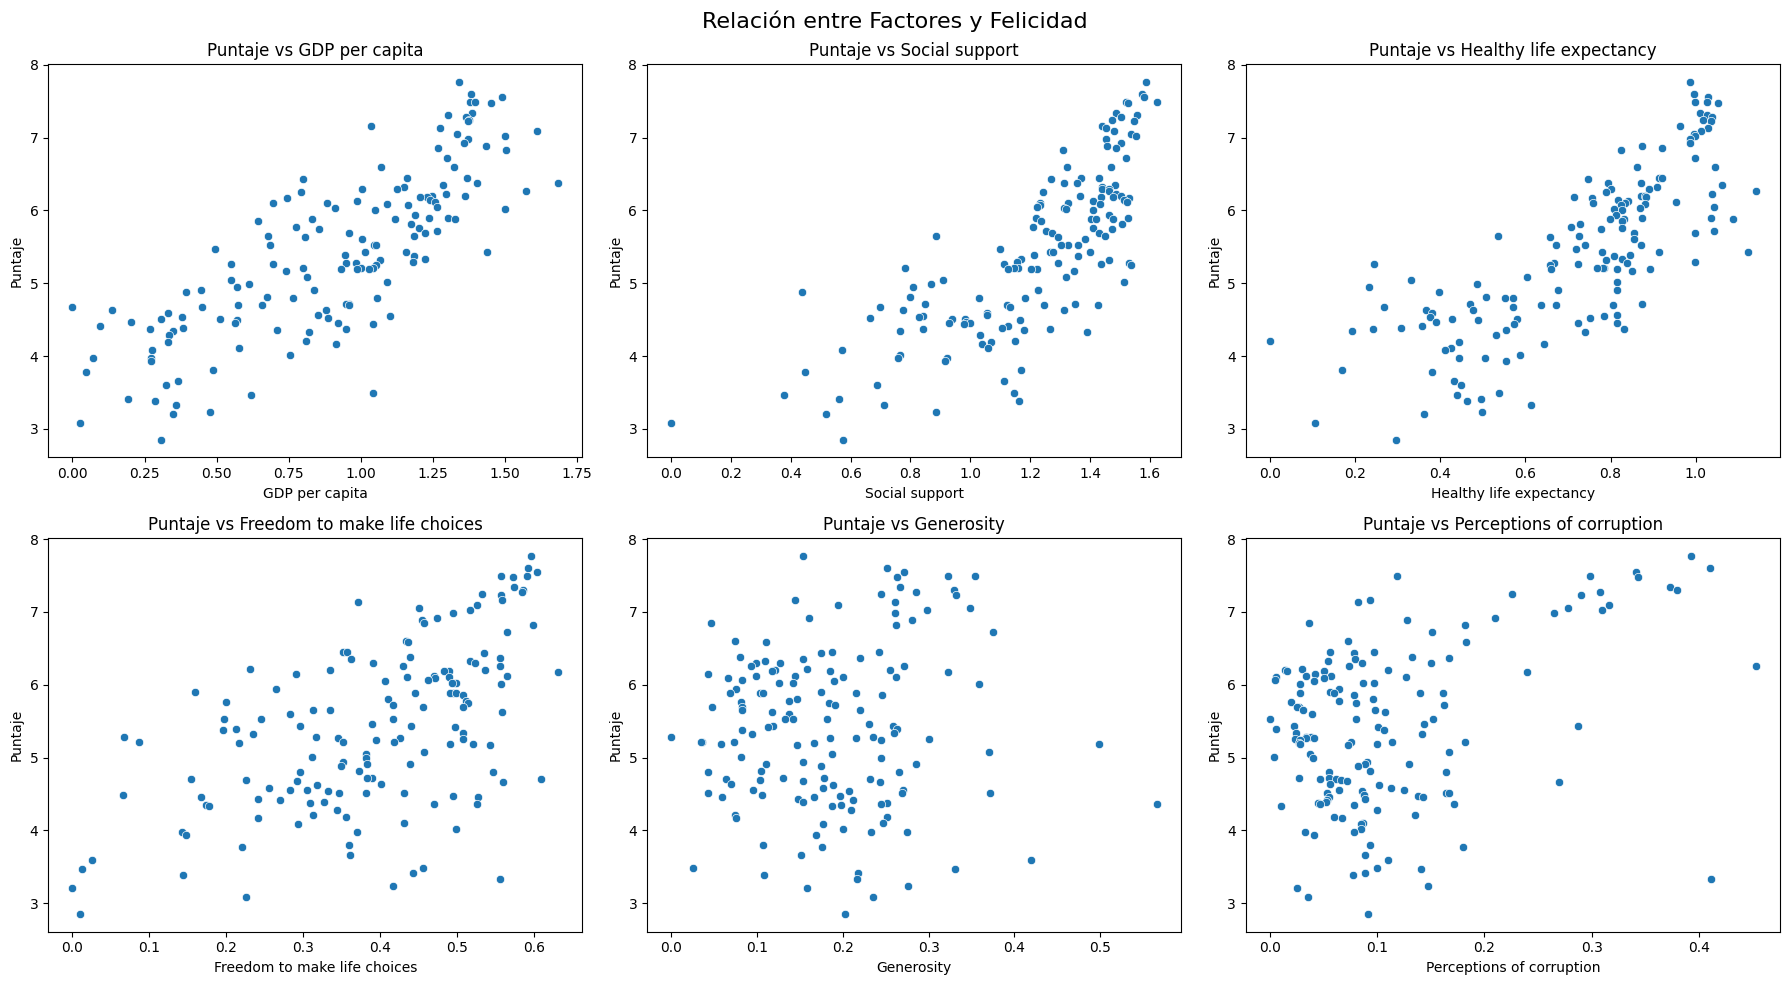

In [63]:
factors = ['GDP per capita', 'Social support', 'Healthy life expectancy',
           'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
for i, factor in enumerate(factors):
    ax = axs[i//3, i%3]
    sns.scatterplot(x=happiness[factor], y=happiness['Score'], ax=ax)
    ax.set_title(f'Puntaje vs {factor}')
    ax.set_xlabel(factor)
    ax.set_ylabel('Puntaje')

fig.suptitle("Relación entre Factores y Felicidad", fontsize=16)

plt.tight_layout()
plt.show()

In [64]:
metadata = pd.read_csv('/content/drive/MyDrive/invierno 2025/Semana TEC python/Metadata.csv')


  Country or region                 Region
0           Finland  Europe & Central Asia
1           Denmark  Europe & Central Asia
2            Norway  Europe & Central Asia
3           Iceland  Europe & Central Asia
4       Netherlands  Europe & Central Asia


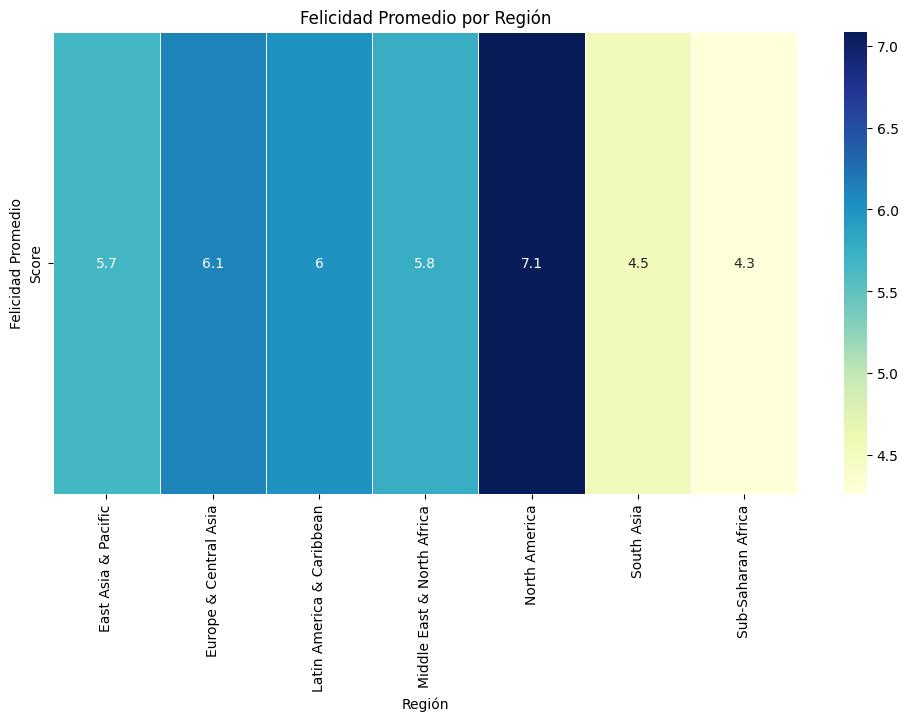

In [65]:
merged_data = happiness.merge(metadata[['TableName', 'Region']],
                              left_on='Country or region',
                              right_on='TableName',
                              how='left')

print(merged_data[['Country or region', 'Region']].head())

felicidad_promedio_region = merged_data.groupby('Region')['Score'].mean().reset_index()

plt.figure(figsize=(12, 6))
heatmap_data = felicidad_promedio_region.set_index('Region').T
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, linewidths=0.5)

plt.title("Felicidad Promedio por Región")
plt.xlabel("Región")
plt.ylabel("Felicidad Promedio")
plt.show()